In [1]:
# ==========================
# IMPORTS
# ==========================

import time

# Device configuration and core PyTorch setup
import torch
import torch.nn as nn
import torch.nn.functional as F
DTYPE = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == "cuda":
    torch.cuda.init()
    torch.rand(1, device=device)
print(f"Using device: {device}")

from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from SA_PINN_ACTO import PINN_Burgers_1D
from IC_1D import ic_burgers

Using device: cuda


In [11]:
# ==========================
# SETUP
# ==========================

# Hyperparameters for network architecture, training schedule, SA and ACTO booleans
Nl, Nn = 5, 50
t_end = 1.0
L = 1.0
nu = 0.01 / np.pi
BC = 'periodic'  # options: 'periodic' or 'dirichlet'
SA = True         # True to turn self-adaptive (SA) masks on; False to remove SA logic, i.e., lambda = 1
ACTO = True       # True to turn on ACTO logic; False to use, instead, the traditional (soft) IC/BC losses
adam_epochs = 15_000
lr_net = 5e-3
lr_mask = 4e-2

# PINN_name label for saving and plotting purposes
if SA and ACTO:
    PINN_name = "SA_ACTO"
elif SA and not ACTO:
    PINN_name = "SA"
elif not SA and ACTO:
    PINN_name = "ACTO"
else:
    PINN_name = "Vanilla"

# Sampling parameters and domain sampling
N_colloc = 15000
N_ic = 1000
N_bc = 1000

def lhs_box(n, low, high, rng=np.random):
    low, high = np.asarray(low, float), np.asarray(high, float)
    D = low.size
    H = np.empty((n, D), float)
    for j in range(D):
        P = (rng.permutation(n) + rng.rand(n)) / n
        H[:, j] = low[j] + P * (high[j] - low[j])
    return H

X_colloc_np = lhs_box(N_colloc, low=np.array([0.0, -L]), high=np.array([t_end, L])).astype(np.float32)

# Construction of initial condition sampling grid
x_edges = np.linspace(-L, L, N_ic + 1)
x_ic = (0.5 * (x_edges[:-1] + x_edges[1:])).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
X_ic = np.hstack((t_ic, x_ic))

X_ic_t = torch.tensor(X_ic, dtype=DTYPE, device=device)
u_ic_t = ic_burgers(X_ic_t, L) # IC burgers

# Construction of boundary-condition sampling grids
t_bc = lhs_box(N_bc, low=np.array([0.0]), high=np.array([t_end])).astype(np.float32)
x_bc_L = -L * np.ones_like(t_bc)
x_bc_R =  L * np.ones_like(t_bc)
X_bc_L_np = np.hstack((t_bc, x_bc_L))
X_bc_R_np = np.hstack((t_bc, x_bc_R))
X_bc_L = torch.tensor(X_bc_L_np, dtype=DTYPE, device=device)
X_bc_R = torch.tensor(X_bc_R_np, dtype=DTYPE, device=device)

# Scaling factors for numerical stability of IC enforcement
with torch.no_grad():
    sU = u_ic_t.abs().max().clamp_min(1e-12).item()
print(f"[scales] sU={sU:.3e}")

# Sorting IC data to enable fast 1D interpolation
x_ic_torch = X_ic_t[:, 1:2].contiguous().view(-1)
x_sorted, idx_sort = torch.sort(x_ic_torch)
u_sorted = u_ic_t.view(-1)[idx_sort]

@torch.no_grad()
def _torch_lin_interp_1d(xq: torch.Tensor, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    xq_flat = xq.view(-1)
    xq_clamped = xq_flat.clamp(min=x[0], max=x[-1])
    idx_hi = torch.searchsorted(x, xq_clamped, right=True)
    idx_hi = idx_hi.clamp(min=1, max=x.numel() - 1)
    idx_lo = idx_hi - 1
    x0 = x[idx_lo]
    x1 = x[idx_hi]
    y0 = y[idx_lo]
    y1 = y[idx_hi]
    denom = (x1 - x0)
    denom = torch.where(denom.abs() > 0, denom, torch.ones_like(denom))
    w = (xq_clamped - x0) / denom
    yq = y0 + w * (y1 - y0)
    return yq.view_as(xq)

# Initial condition function passed to the PINN (physical scale)
def u_ic_func(x_phys: torch.Tensor) -> torch.Tensor:
    if x_sorted.device != x_phys.device or x_sorted.dtype != x_phys.dtype:
        xk = x_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
        yk = u_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
    else:
        xk, yk = x_sorted, u_sorted
    yq = _torch_lin_interp_1d(x_phys.view(-1), xk, yk)
    return yq.view(-1, 1)

# Scaled initial condition function (used internally by the PINN when ACTO=True)
def u_ic_func_scaled(x_phys: torch.Tensor) -> torch.Tensor:
    return u_ic_func(x_phys) / sU

# Dirichlet boundary-value function (physical scale)
def dirichlet_bc_func(X_phys: torch.Tensor) -> torch.Tensor:
    return torch.zeros((X_phys.shape[0], 1), dtype=X_phys.dtype, device=X_phys.device)

# Scaled Dirichlet boundary-value function (used internally by the PINN when ACTO=True)
def dirichlet_bc_func_scaled(X_phys: torch.Tensor) -> torch.Tensor:
    return dirichlet_bc_func(X_phys) / sU

X_colloc = torch.tensor(X_colloc_np, dtype=DTYPE, device=device)
x0_line = torch.linspace(-L, L, 500, dtype=DTYPE, device=device).unsqueeze(1)
X0 = torch.cat([torch.zeros_like(x0_line), x0_line], dim=1)
X_colloc = torch.cat([X_colloc, X0], dim=0)

# Self-adaptive masks
pde_logits = torch.nn.Parameter(torch.zeros((X_colloc.shape[0], 1), dtype=DTYPE, device=device))
ic_logits = torch.nn.Parameter(torch.zeros((X_ic_t.shape[0], 1), dtype=DTYPE, device=device))
bc_mask_size = X_bc_L.shape[0] if BC.lower() == 'periodic' else 2 * X_bc_L.shape[0]
bc_logits = torch.nn.Parameter(torch.zeros((bc_mask_size, 1), dtype=DTYPE, device=device))

def current_masks(detach: bool = False):
    if SA:
        pde = F.softplus(pde_logits)
        ic = F.softplus(ic_logits)
        bc = F.softplus(bc_logits)
    else:
        pde = torch.ones_like(pde_logits)
        ic = torch.ones_like(ic_logits)
        bc = torch.ones_like(bc_logits)

    if detach:
        pde = pde.detach()
        ic = ic.detach()
        bc = bc.detach()

    return pde, ic, bc

# Model instantiation and domain normalization
lb = torch.tensor([0.0, -L], dtype=DTYPE, device=device)
ub = torch.tensor([t_end, L], dtype=DTYPE, device=device)
model = PINN_Burgers_1D(Nl=Nl, Nn=Nn, lb=lb, ub=ub, nu=nu, BC=BC, ACTO=ACTO).to(device).to(DTYPE)
model.BC = BC.lower()
model.ACTO = ACTO
model.u_ic_phys_func = u_ic_func
model.u_ic_func = u_ic_func_scaled
if model.BC == 'dirichlet':
    model.u_bc_phys_func = dirichlet_bc_func
    model.u_bc_func = dirichlet_bc_func_scaled
model.sU.copy_(torch.tensor(sU, dtype=DTYPE, device=device))

# Weight initialization
def glorot_normal_all_linear(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
model.apply(glorot_normal_all_linear)

# Optimizers and learning-rate scheduler setup
optimizer_theta = torch.optim.Adam(model.parameters(), lr=lr_net, betas=(0.9, 0.95))
scheduler = ReduceLROnPlateau(optimizer_theta, mode='min', factor=0.4, patience=700, threshold=1e-4, min_lr=lr_net / 100)
optimizer_mask = torch.optim.Adam([pde_logits, ic_logits, bc_logits], lr=lr_mask, betas=(0.7, 0.85), maximize=True)

def compute_losses(use_masks: bool):
    R = model.pde_residual(X_colloc)
    L_pde_phys = (R ** 2).mean()

    if use_masks:
        pde_mask, ic_mask, bc_mask = current_masks(detach=False)
        L_pde = (pde_mask * torch.abs(R)).pow(2).mean()
    else:
        pde_mask, ic_mask, bc_mask = current_masks(detach=True)
        L_pde = L_pde_phys

    zero = torch.zeros((), dtype=DTYPE, device=device)

    if ACTO:
        L_ic = zero
        L_bc = zero
        L_ic_phys = zero
        L_bc_phys = zero
    else:
        ic_res = model.ic_residual(X_ic_t, u_ic_target=u_ic_t)
        bc_res = model.bc_residual(X_bc_L, X_bc_R)

        L_ic_phys = (ic_res ** 2).mean()
        L_bc_phys = (bc_res ** 2).mean()

        if use_masks:
            L_ic = (ic_mask * torch.abs(ic_res)).pow(2).mean()
            L_bc = (bc_mask * torch.abs(bc_res)).pow(2).mean()
        else:
            L_ic = L_ic_phys
            L_bc = L_bc_phys

    L_total = L_pde + L_ic + L_bc
    L_total_phys = L_pde_phys + L_ic_phys + L_bc_phys

    return {
        'L_total': L_total,
        'L_pde': L_pde,
        'L_ic': L_ic,
        'L_bc': L_bc,
        'L_total_phys': L_total_phys,
        'L_pde_phys': L_pde_phys,
        'L_ic_phys': L_ic_phys,
        'L_bc_phys': L_bc_phys,
        'pde_mask': pde_mask,
        'ic_mask': ic_mask,
        'bc_mask': bc_mask,
    }

# Setting up and executing Adam pre-training
def train_adam(model, optimizer_theta, optimizer_mask, epochs, print_every):
    print(f"Starting Adam pre-training | SA={SA} | ACTO={ACTO} | BC='{BC}'")
    best_loss, best_state = float('inf'), None
    loss_history = []

    for epoch in range(1, epochs + 1):
        optimizer_theta.zero_grad()
        optimizer_mask.zero_grad()

        losses = compute_losses(use_masks=True)
        loss = losses['L_total']

        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite loss detected.')

        loss.backward()
        optimizer_theta.step()
        scheduler.step(losses['L_total_phys'].item())
        optimizer_mask.step()

        ltp = losses['L_total_phys'].detach().item()
        loss_history.append(ltp)
        if ltp < best_loss:
            best_loss = ltp
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % print_every == 0 or epoch == epochs:
            m_pde = current_masks(detach=True)[0]
            msg = (f"Adam Epoch {epoch}/{epochs} | "
                   f"Masked: Total={losses['L_total'].item():.3e}, PDE={losses['L_pde'].item():.3e}")
            if not ACTO:
                msg += f", IC={losses['L_ic'].item():.3e}, BC={losses['L_bc'].item():.3e}"
            msg += (f" | Unmasked: Total={losses['L_total_phys'].item():.3e}, PDE={losses['L_pde_phys'].item():.3e}")
            if not ACTO:
                msg += f", IC={losses['L_ic_phys'].item():.3e}, BC={losses['L_bc_phys'].item():.3e}"
            msg += f" | <pde_mask>={m_pde.mean().item():.2f} | lr_net={optimizer_theta.param_groups[0]['lr']:.3e}"
            print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)
        losses = compute_losses(use_masks=False)
        print(f"\nAdam finished. Best unmasked total loss = {best_loss:.3e} | "
              f"PDE={losses['L_pde_phys'].item():.4e}"
              + ("" if ACTO else f", IC={losses['L_ic_phys'].item():.4e}, BC={losses['L_bc_phys'].item():.4e}"))

    return best_loss, loss_history, best_state

[scales] sU=1.000e+00


In [12]:
# ==========================
# TRAINING
# ==========================

start_training = time.time()
adam_loss, adam_loss_history, best_state = train_adam(model, optimizer_theta, optimizer_mask, adam_epochs, print_every=1000)
adam_training_finished = time.time()

model.load_state_dict(best_state)

# Setting up and executing L-BFGS fine-tuning
with torch.enable_grad():
    init_lbfgs_loss = compute_losses(use_masks=False)['L_total_phys'].detach().item()
print(f"LBFGS init unmasked total loss (from best Adam): {init_lbfgs_loss:.3e}")

loss_scale = 1.0 / max(init_lbfgs_loss, 1e-30)

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=1000,
    max_eval=1000,
    history_size=100,
    line_search_fn=None,
    tolerance_grad=1e-10,
    tolerance_change=1e-12,
)

best = {'loss': float('inf'), 'state': None}
inner_curve = []

def closure():
    optimizer_lbfgs.zero_grad(set_to_none=True)
    losses = compute_losses(use_masks=False)
    raw = losses['L_total_phys']

    if not torch.isfinite(raw):
        print(f"NaN/Inf detected at iter {len(inner_curve)}. Exiting L-BFGS.")
        raise RuntimeError('L-BFGS_NAN')

    loss = raw * loss_scale

    raw_f = float(raw)
    if raw_f < best['loss']:
        best['loss'] = raw_f
        best['state'] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    inner_curve.append(raw_f)

    loss.backward()
    return loss

lbfgs_training_started = time.time()
try:
    final_loss = optimizer_lbfgs.step(closure)
    final_raw = float(final_loss.item()) / loss_scale
except RuntimeError as e:
    if 'L-BFGS_NAN' in str(e):
        print('L-BFGS terminated early due to NaN/Inf.')
        final_raw = float('nan')
    else:
        raise
end_training = time.time()

# Restore best L-BFGS state and record loss history
if best['state'] is not None:
    model.load_state_dict(best['state'])

lbfgs_loss_history = inner_curve

print(f"LBFGS finished. final_raw={final_raw:.4e} | best_raw={best['loss']:.4e} | inner_calls={len(inner_curve)}")

print(f"\nTotal training time: {end_training - start_training:.4f} seconds."
      f"\nAdam: {adam_training_finished - start_training:.4f} seconds. "
      f"L-BFGS: {end_training - lbfgs_training_started:.4f} seconds.")

Starting Adam pre-training | SA=True | ACTO=True | BC='periodic'
Adam Epoch 1000/15000 | Masked: Total=1.599e+01, PDE=1.599e+01 | Unmasked: Total=2.185e-02, PDE=2.185e-02 | <pde_mask>=29.94 | lr_net=5.000e-03
Adam Epoch 2000/15000 | Masked: Total=1.872e+01, PDE=1.872e+01 | Unmasked: Total=5.957e-03, PDE=5.957e-03 | <pde_mask>=59.35 | lr_net=5.000e-03
Adam Epoch 3000/15000 | Masked: Total=6.833e+01, PDE=6.833e+01 | Unmasked: Total=9.644e-03, PDE=9.644e-03 | <pde_mask>=87.10 | lr_net=5.000e-03
Adam Epoch 4000/15000 | Masked: Total=6.346e+01, PDE=6.346e+01 | Unmasked: Total=4.963e-03, PDE=4.963e-03 | <pde_mask>=113.51 | lr_net=5.000e-03
Adam Epoch 5000/15000 | Masked: Total=2.652e+01, PDE=2.652e+01 | Unmasked: Total=1.367e-03, PDE=1.367e-03 | <pde_mask>=139.64 | lr_net=2.000e-03
Adam Epoch 6000/15000 | Masked: Total=1.897e+01, PDE=1.897e+01 | Unmasked: Total=6.869e-04, PDE=6.869e-04 | <pde_mask>=167.14 | lr_net=2.000e-03
Adam Epoch 7000/15000 | Masked: Total=2.419e+01, PDE=2.419e+01 | Unm

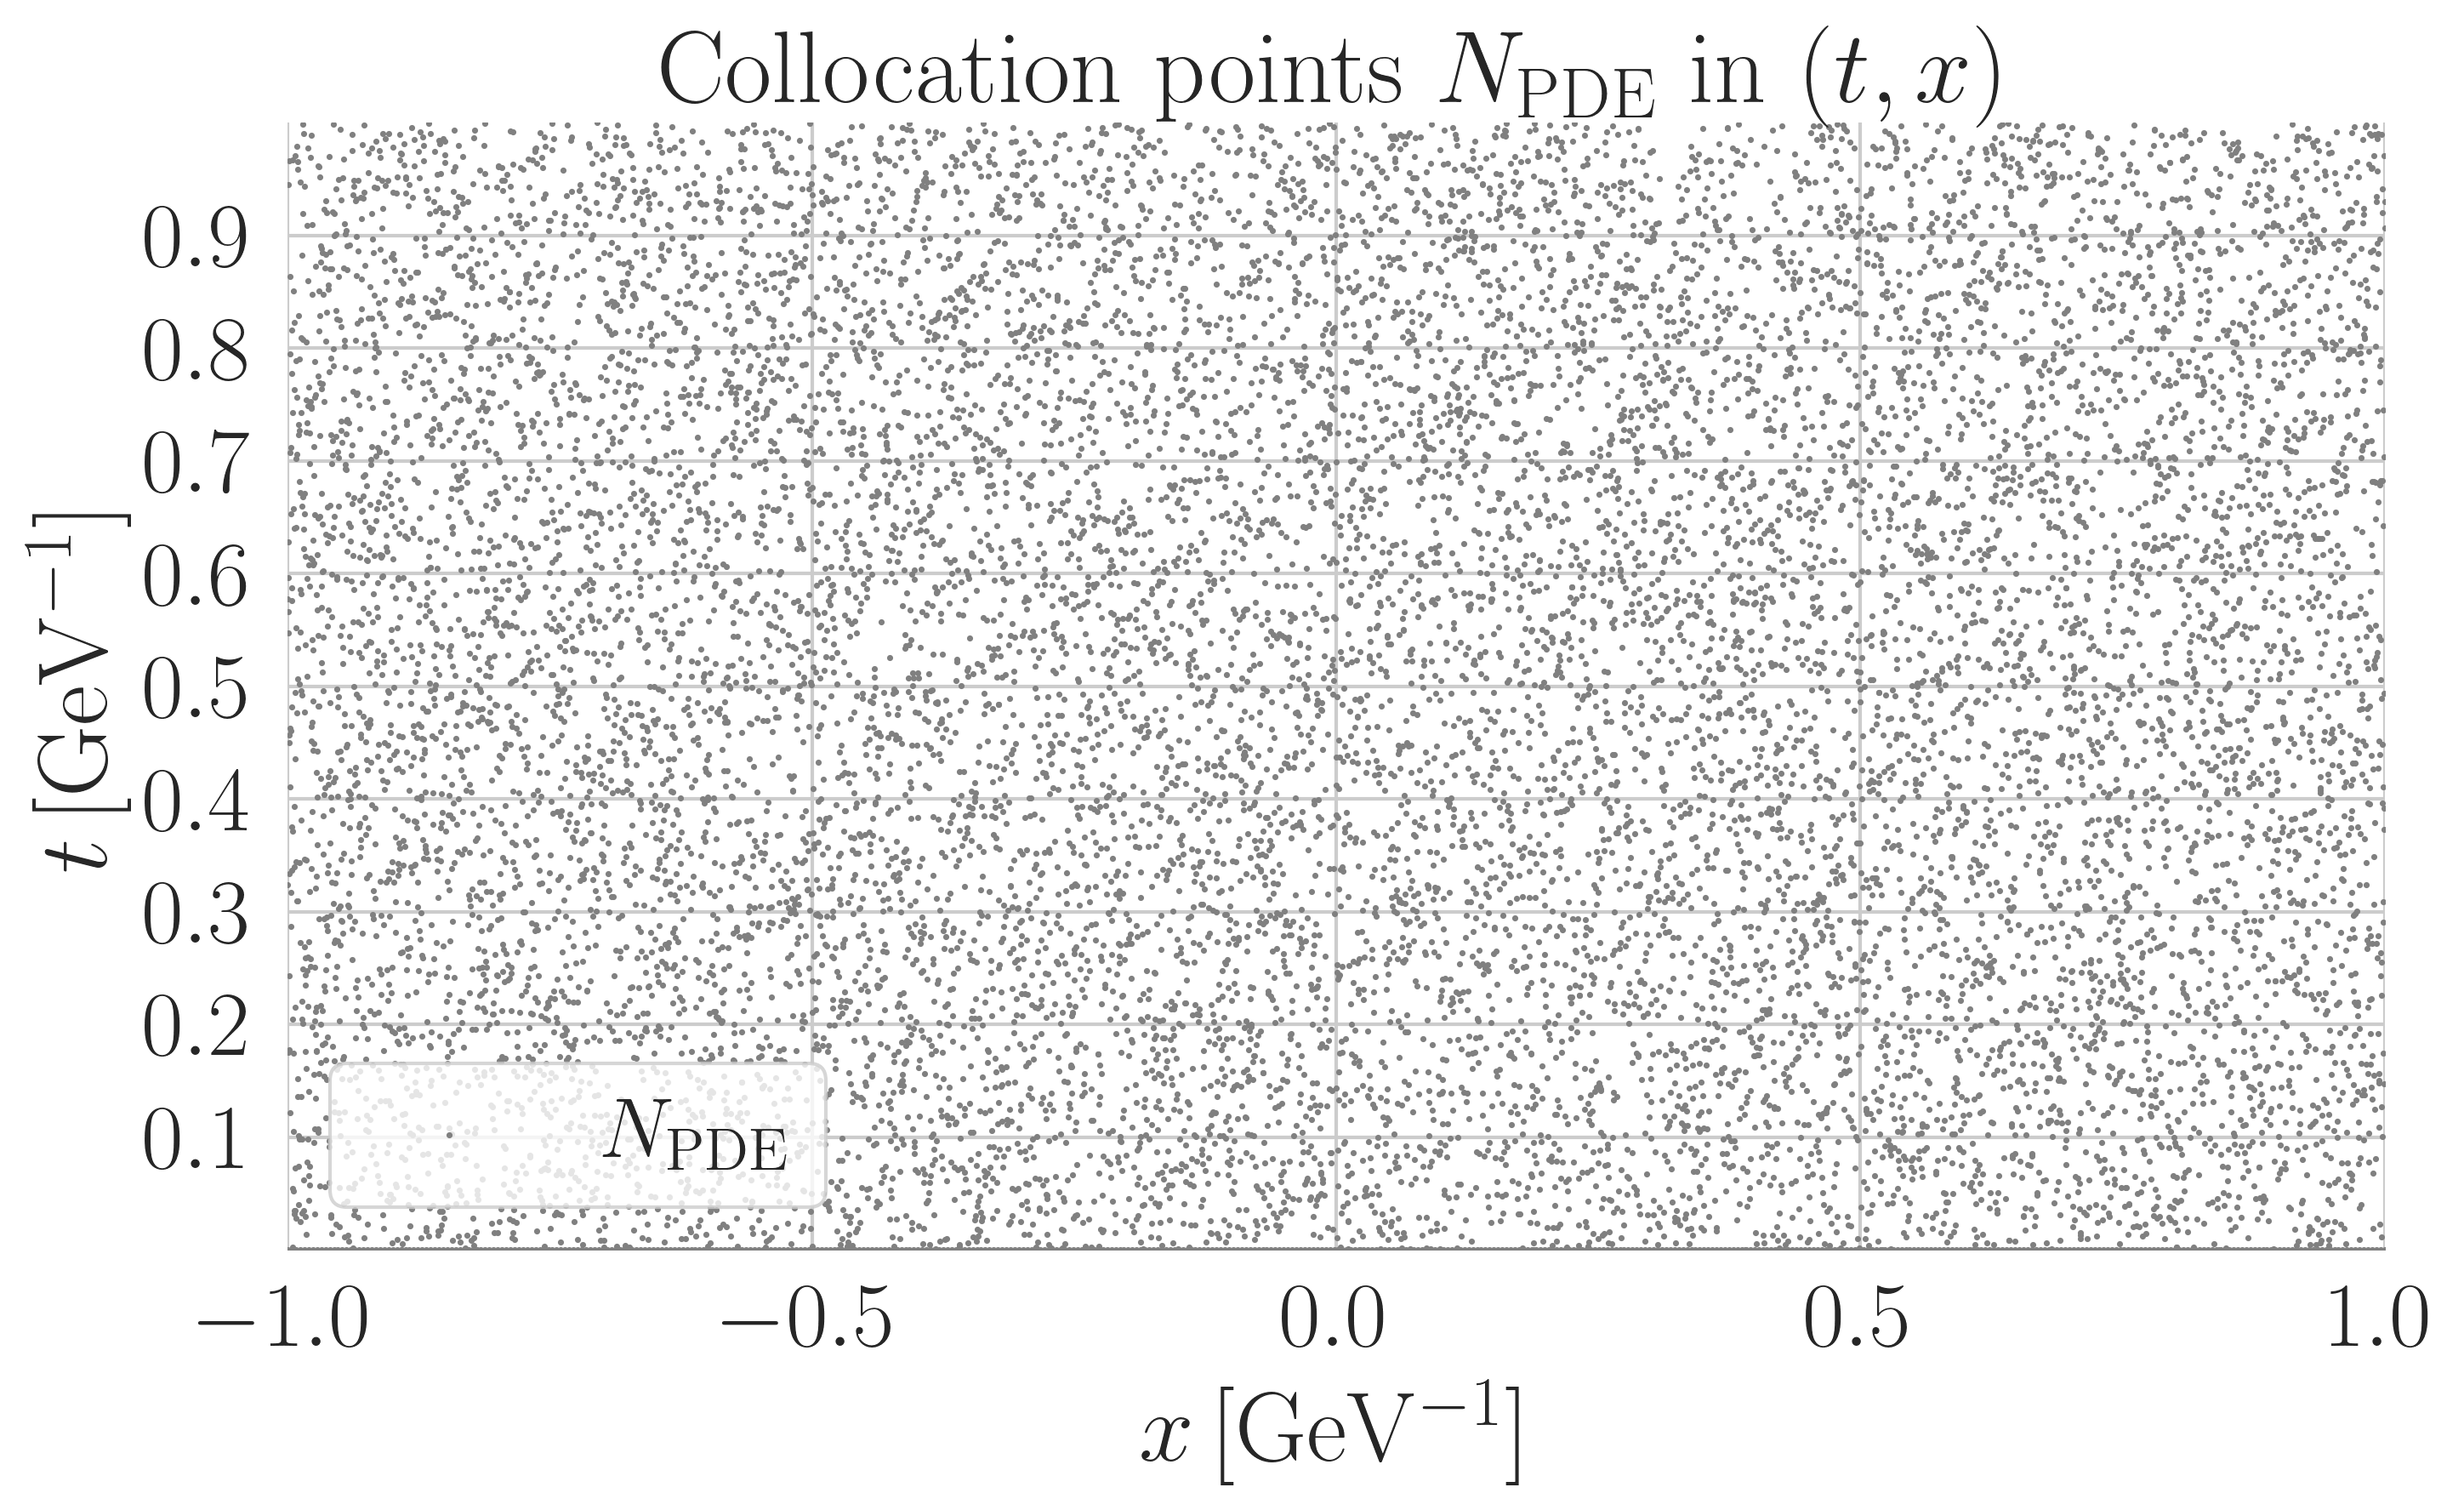

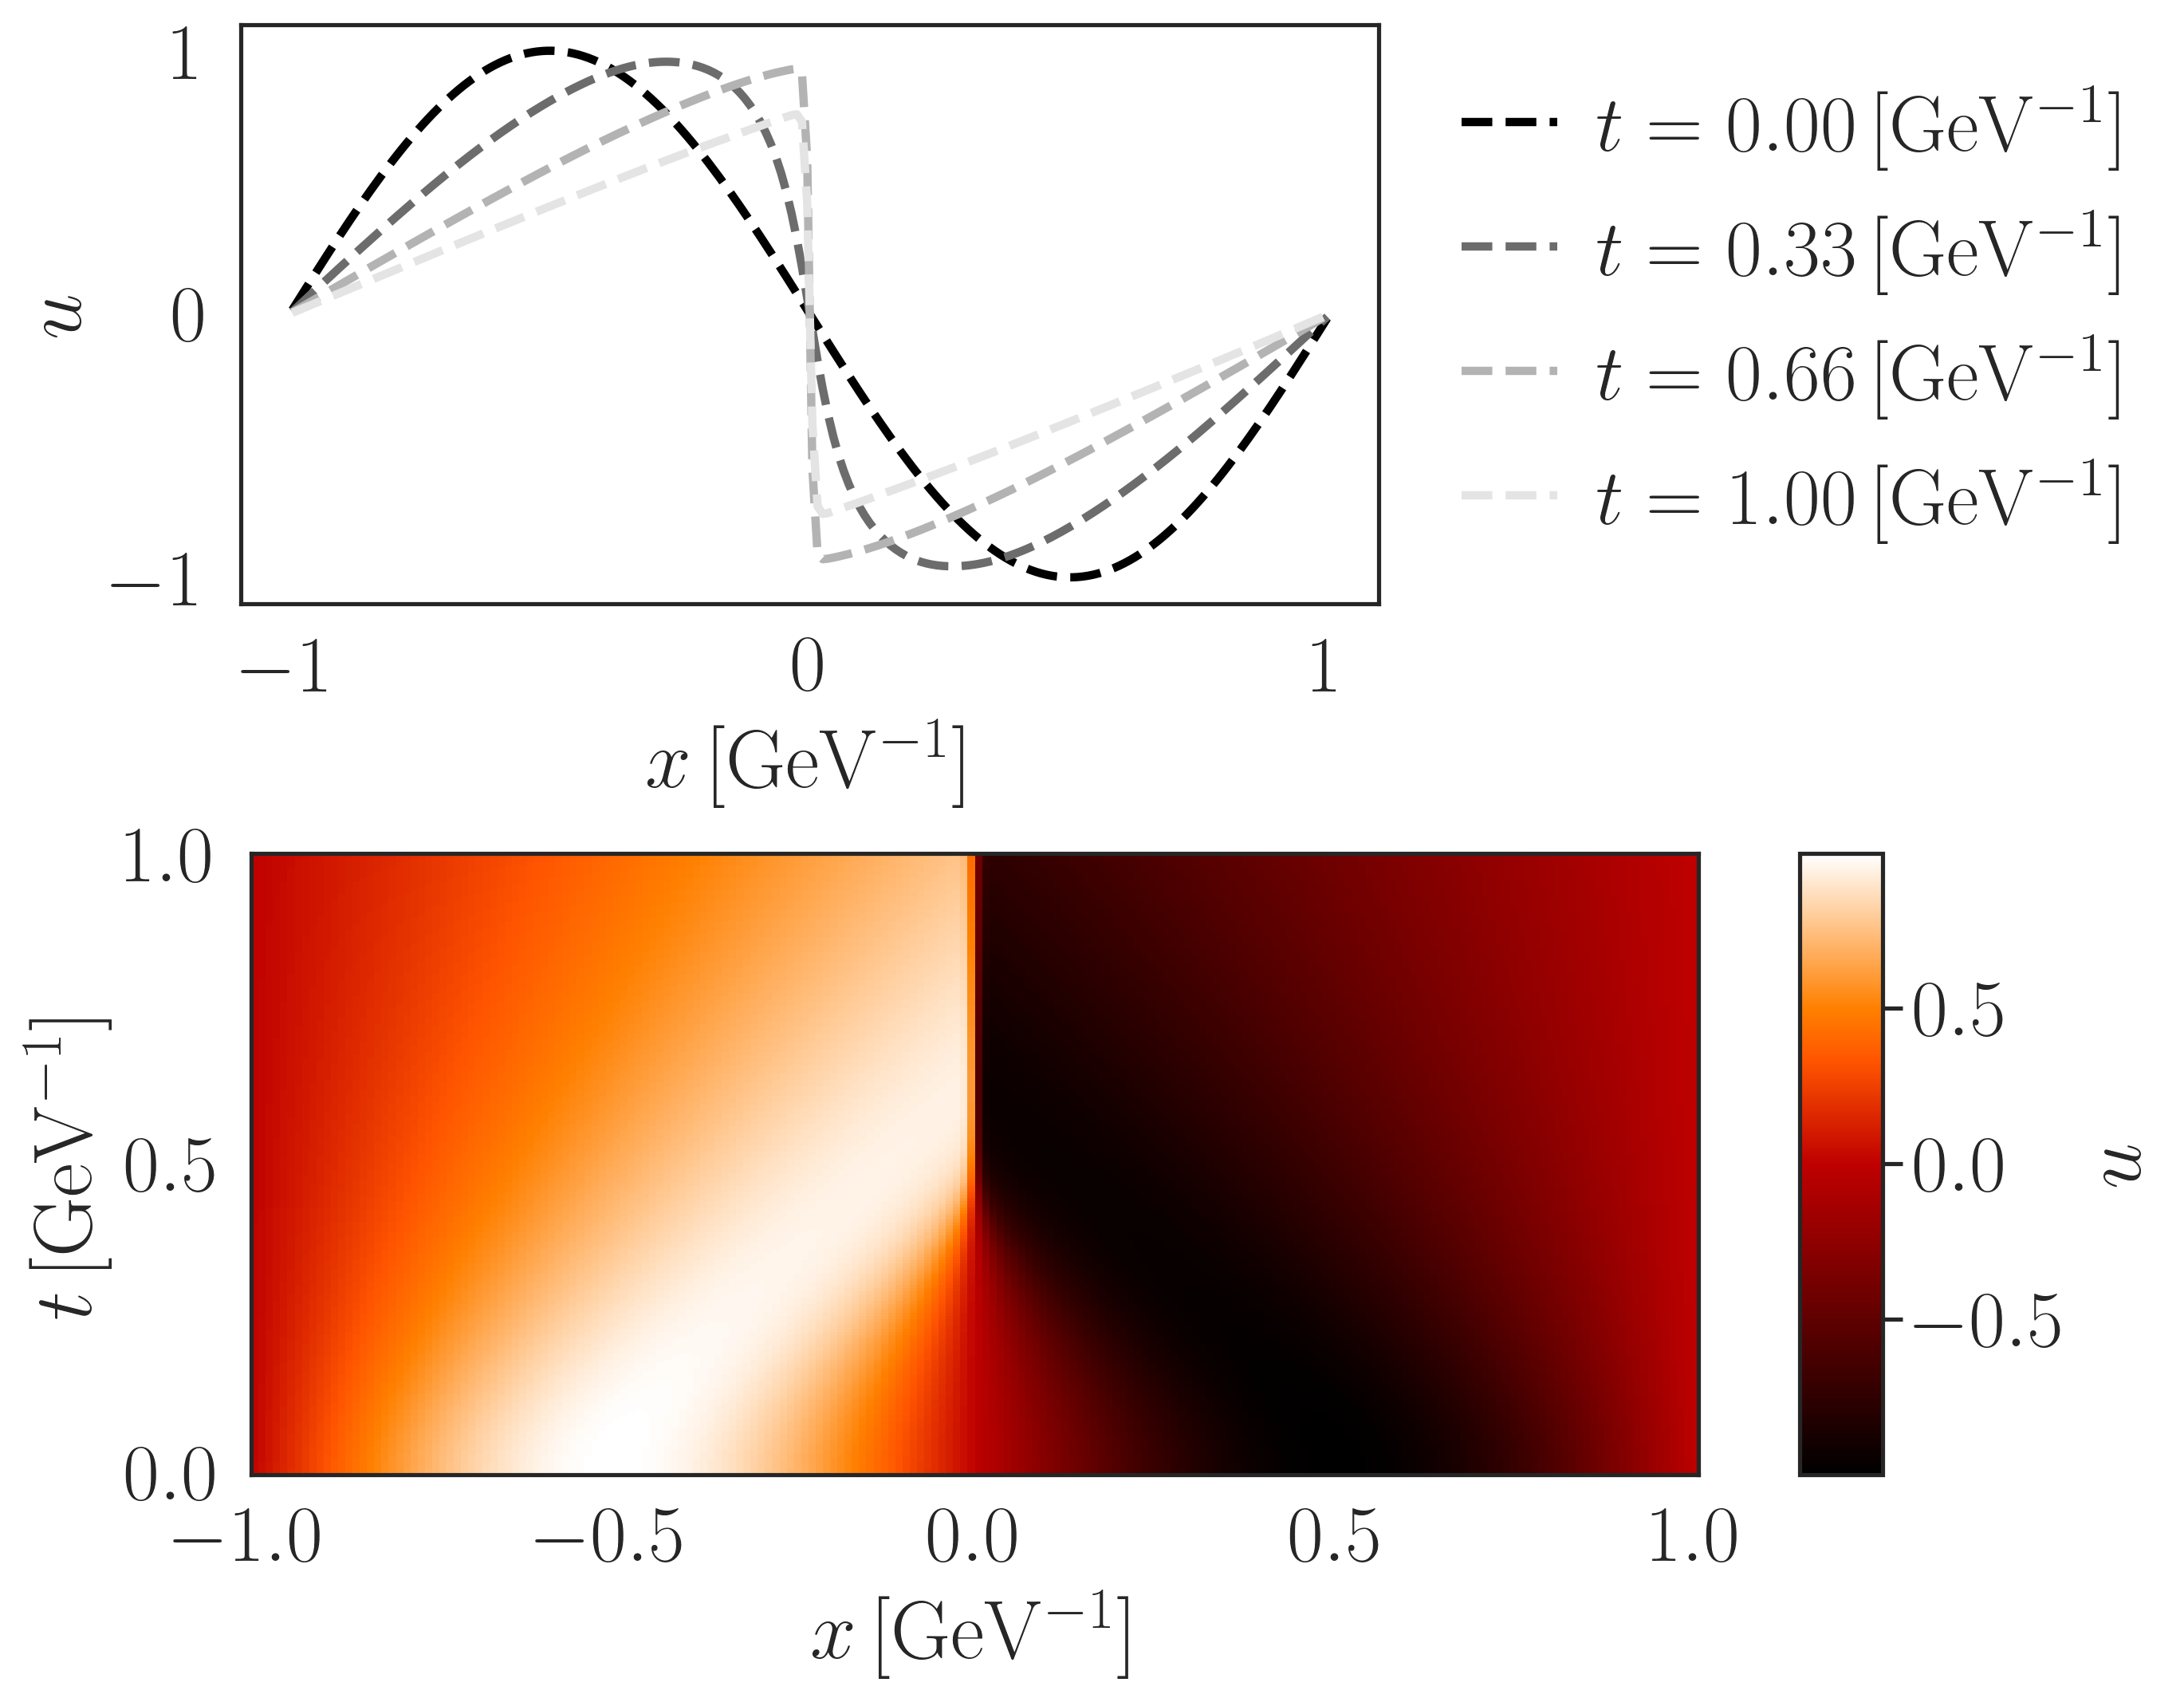

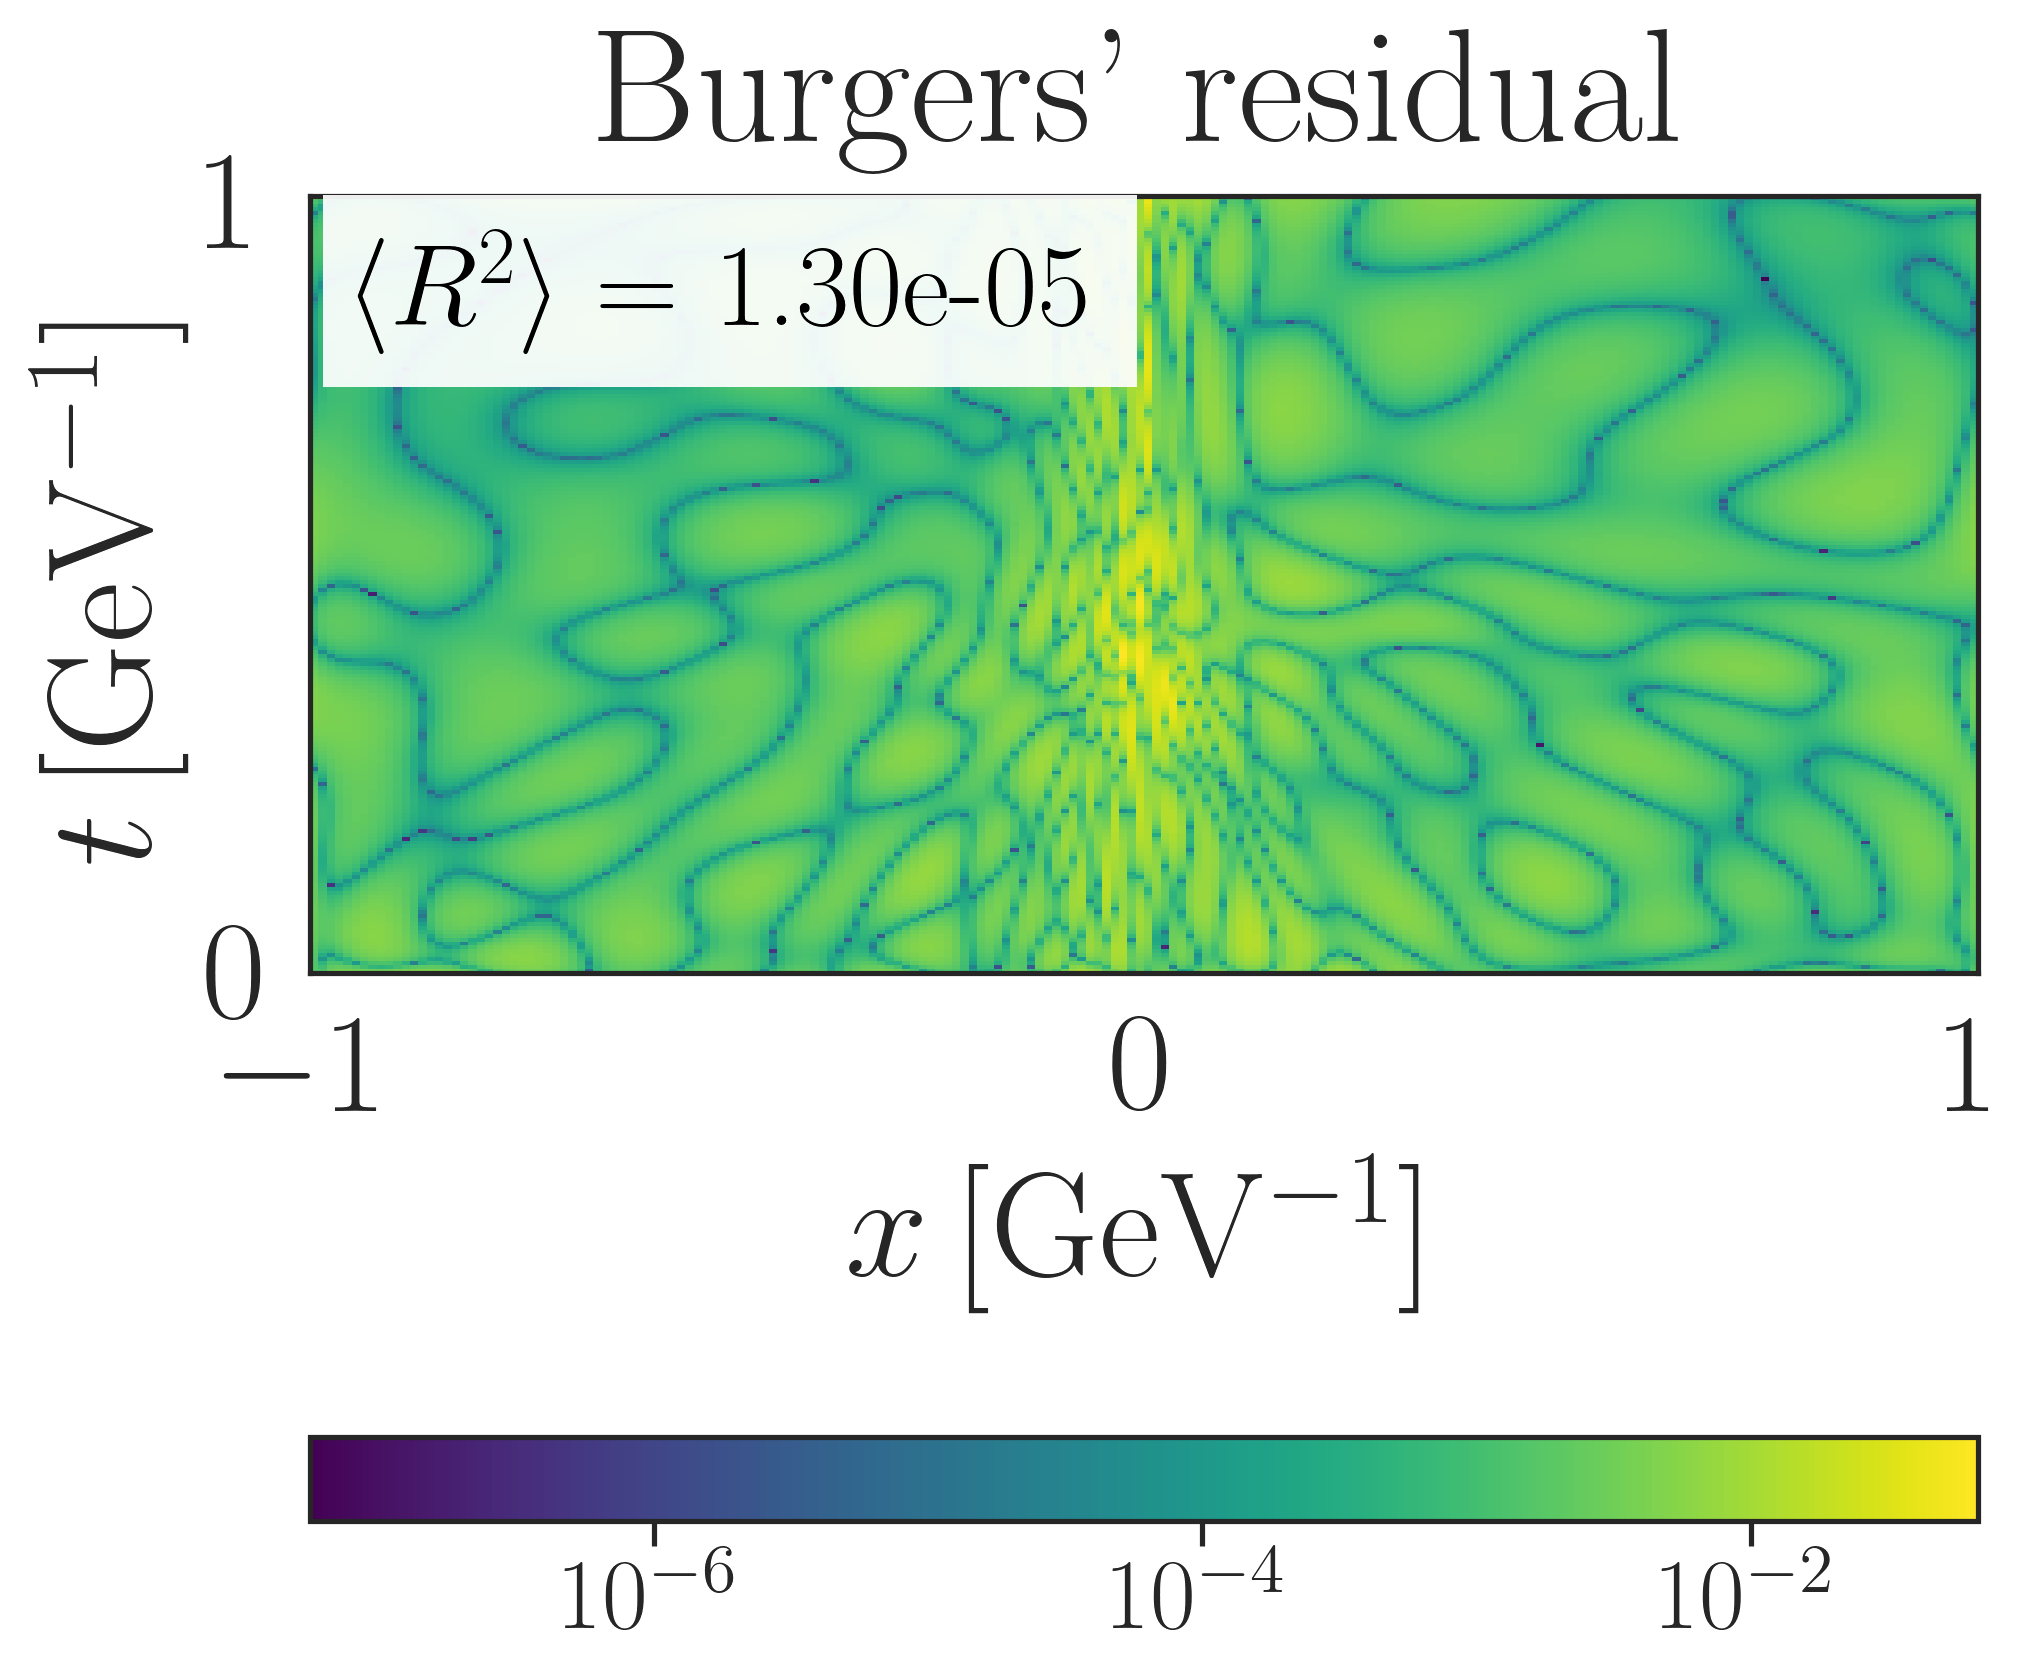

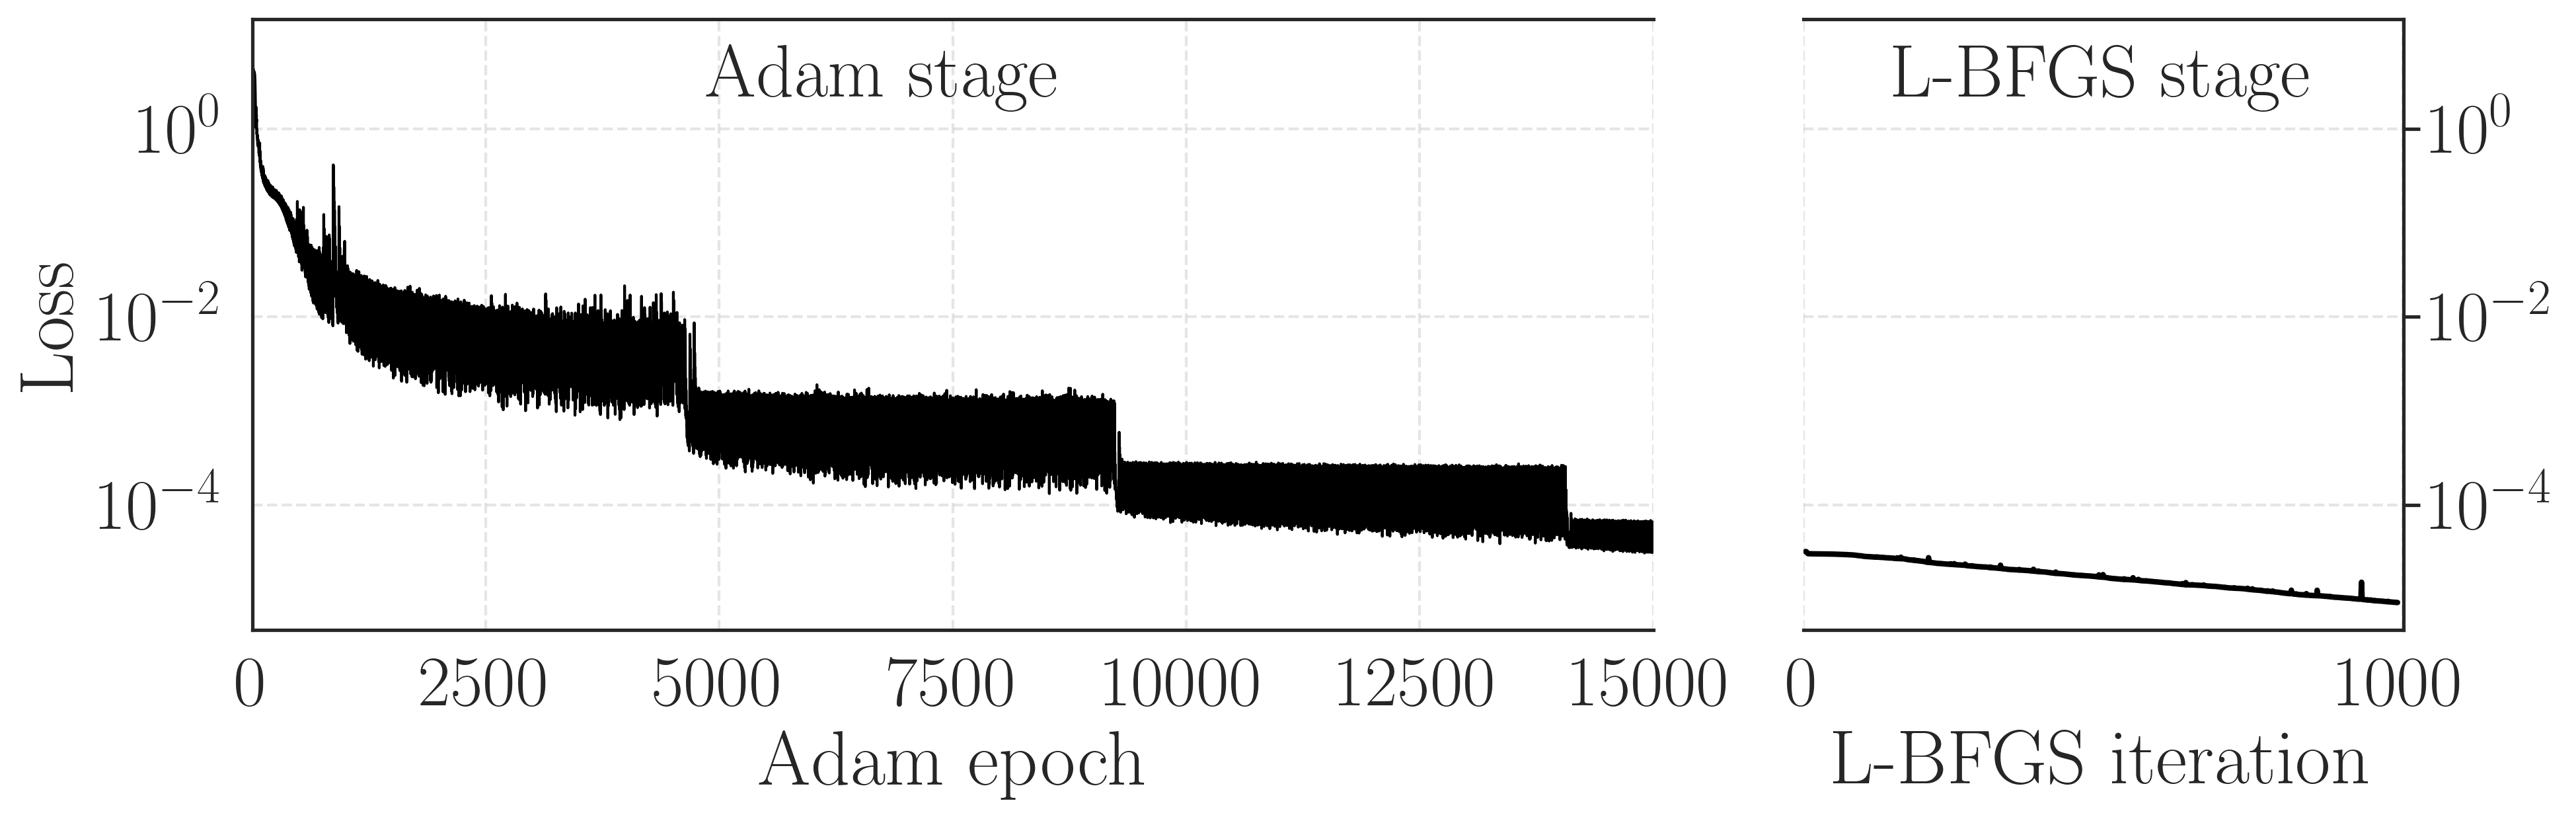

In [13]:
# ==========================
# PLOTTING
# ==========================

from Plotting import *

plot_collocation_points(
    X_colloc,
    X_ic=None if ACTO else X_ic_t,
    X_bc_L=None if ACTO else X_bc_L,
    X_bc_R=None if ACTO else X_bc_R,
    L=L,
    t_end=t_end
)

u_ic_np = u_ic_t.detach().cpu().numpy()

x_edges_eval = np.linspace(-L, L, 200 + 1)
x_eval = 0.5 * (x_edges_eval[:-1] + x_edges_eval[1:])
t_eval = np.linspace(0, t_end, 200)

plot_results(
    model,
    t_eval=t_eval,
    x_eval=x_eval,
    u_ic=u_ic_t.detach().cpu().numpy()
)

with torch.enable_grad():
    plot_pde_residuals(model, t_eval, x_eval)

lbfgs_history = {'all_inner_per_epoch': [lbfgs_loss_history]}
plot_combined_loss_history(adam_loss_history, lbfgs_history)

In [14]:
# ==========================
# SAVING
# ==========================

import os, time
from typing import Dict, Any

def _as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

@torch.no_grad()
def _eval_on_grid(model, t_eval: np.ndarray, x_eval: np.ndarray, batch_size: int = 32768):
    was_training = model.training
    model.eval()

    t_eval = np.asarray(t_eval, dtype=np.float32).ravel()
    x_eval = np.asarray(x_eval, dtype=np.float32).ravel()
    Nt, Nx = len(t_eval), len(x_eval)

    TT, XX = np.meshgrid(t_eval, x_eval, indexing='ij')
    TX = np.stack([TT.reshape(-1), XX.reshape(-1)], axis=1)

    TX_t = torch.tensor(TX, dtype=DTYPE, device=device, requires_grad=True)
    r_list = []
    with torch.enable_grad():
        for i in range(0, TX_t.shape[0], batch_size):
            r = model.pde_residual(TX_t[i:i + batch_size])
            r_list.append(r)
        r_all = torch.cat(r_list, dim=0)
    r_grid = r_all.view(Nt, Nx, -1).detach().cpu().numpy()

    pred_grid = None
    pred_names = None
    u_grid = np.array([], dtype=np.float32)

    with torch.no_grad():
        y_list = []
        for i in range(0, TX.shape[0], batch_size):
            y = model(torch.tensor(TX[i:i + batch_size], dtype=DTYPE, device=device))

            if isinstance(y, (list, tuple)):
                parts = []
                for yi in y:
                    yi = yi if yi.ndim == 2 else yi.view(yi.shape[0], -1)
                    parts.append(yi)
                y = torch.cat(parts, dim=1)
                pred_names = [f'out{i}' for i in range(y.shape[1])]
            elif isinstance(y, dict):
                keys = list(y.keys())
                parts = []
                for k in keys:
                    yi = y[k]
                    yi = yi if yi.ndim == 2 else yi.view(yi.shape[0], -1)
                    parts.append(yi)
                y = torch.cat(parts, dim=1)
                pred_names = keys
            else:
                if y.ndim == 1:
                    y = y.unsqueeze(1)
                elif y.ndim > 2:
                    y = y.view(y.shape[0], -1)
                if pred_names is None:
                    pred_names = [f'out{i}' for i in range(y.shape[1])]

            y_list.append(y.detach().cpu())

        if y_list:
            y_all = torch.cat(y_list, dim=0).numpy()
            pred_grid = y_all.reshape(Nt, Nx, -1)
            u_grid = pred_grid[:, :, 0].astype(np.float32)

    if was_training:
        model.train()

    return {
        't_eval': t_eval,
        'x_eval': x_eval,
        'TX': TX.astype(np.float32),
        'r_pde_grid': r_grid,
        'pred_grid': pred_grid if pred_grid is not None else None,
        'pred_names': np.array(pred_names, dtype=object) if pred_names is not None else None,
        'u_grid': u_grid,
    }

def _compute_residual_field(model, t_eval: np.ndarray, x_eval: np.ndarray):
    model.eval()

    p = next(model.parameters())
    dev, dty = p.device, p.dtype

    t_eval = np.asarray(t_eval, dtype=np.float64).ravel()
    x_eval = np.asarray(x_eval, dtype=np.float64).ravel()
    Nt, Nx = len(t_eval), len(x_eval)

    tt, xx = np.meshgrid(t_eval, x_eval, indexing='ij')
    tx = np.column_stack([tt.ravel(), xx.ravel()])
    tx_tensor = torch.tensor(tx, dtype=dty, device=dev, requires_grad=True)

    with torch.set_grad_enabled(True):
        R = model.pde_residual(tx_tensor)

    return {
        'R_grid': R.detach().cpu().numpy().reshape(Nt, Nx),
    }

res_fields = _compute_residual_field(model, t_eval=t_eval, x_eval=x_eval)
grid_dump = _eval_on_grid(model, t_eval=t_eval, x_eval=x_eval)
run_id = time.strftime('%Y%m%d-%H%M%S')
save_dir = os.path.abspath('./pinn_runs')
os.makedirs(save_dir, exist_ok=True)
dump_path = os.path.join(save_dir, f'{PINN_name}_PINN_{BC}_run_dump_{run_id}.npz')

lbfgs_all_inner = np.array(lbfgs_history['all_inner_per_epoch'], dtype=object) if 'all_inner_per_epoch' in lbfgs_history else np.array([], dtype=object)
lbfgs_inner_curve_np = np.asarray(lbfgs_loss_history, dtype=np.float64)

np.savez_compressed(
    dump_path,
    run_id=run_id, dtype=str(DTYPE), device_type=str(device.type),
    t_end=float(t_end), L=float(L), nu=float(nu), BC=str(BC), SA=bool(SA), ACTO=bool(ACTO),

    X_colloc=_as_numpy(X_colloc),
    X_bc_L=_as_numpy(X_bc_L) if 'X_bc_L' in globals() and X_bc_L is not None else np.array([]),
    X_bc_R=_as_numpy(X_bc_R) if 'X_bc_R' in globals() and X_bc_R is not None else np.array([]),
    x_ic=_as_numpy(x_ic), t_ic=_as_numpy(t_ic),
    u_ic=_as_numpy(u_ic_np),

    t_eval=grid_dump['t_eval'], x_eval=grid_dump['x_eval'], TX=grid_dump['TX'],
    pred_grid=grid_dump['pred_grid'] if grid_dump['pred_grid'] is not None else np.array([]),
    pred_names=grid_dump['pred_names'] if grid_dump['pred_names'] is not None else np.array([], dtype=object),
    u_grid=grid_dump['u_grid'],
    r_pde_grid=grid_dump['r_pde_grid'],

    R_grid=res_fields['R_grid'],

    adam_loss_history=np.asarray(adam_loss_history, dtype=np.float64),
    lbfgs_final_per_epoch=np.asarray(lbfgs_history.get('final_per_epoch', []), dtype=np.float64),
    lbfgs_best_inner_per_epoch=np.asarray(lbfgs_history.get('best_inner_per_epoch', []), dtype=np.float64),
    lbfgs_num_closure_calls=np.asarray(lbfgs_history.get('num_closure_calls', []), dtype=np.int32),
    lbfgs_all_inner_per_epoch=lbfgs_all_inner,

    lbfgs_inner_curve=lbfgs_inner_curve_np,
    
    # ===== TIME INFO =====
    start_training_time=np.asarray(start_training, dtype=np.float64),
    end_training_time=np.asarray(end_training, dtype=np.float64),
    total_training_time=np.asarray(end_training - start_training, dtype=np.float64),
    adam_time=np.asarray(adam_training_finished - start_training, dtype=np.float64),
    lbfgs_time=np.asarray(end_training - lbfgs_training_started, dtype=np.float64)
)
print(f'[save] Dumped replot data to: {dump_path}')

[save] Dumped replot data to: /home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/pinn_runs/SA_ACTO_PINN_periodic_run_dump_20260429-034906.npz


### Load and extract information


82.21077036857605
11.877208232879639
94.091073513031


ValueError: x and y must have same first dimension, but have shapes (1,) and (15000,)

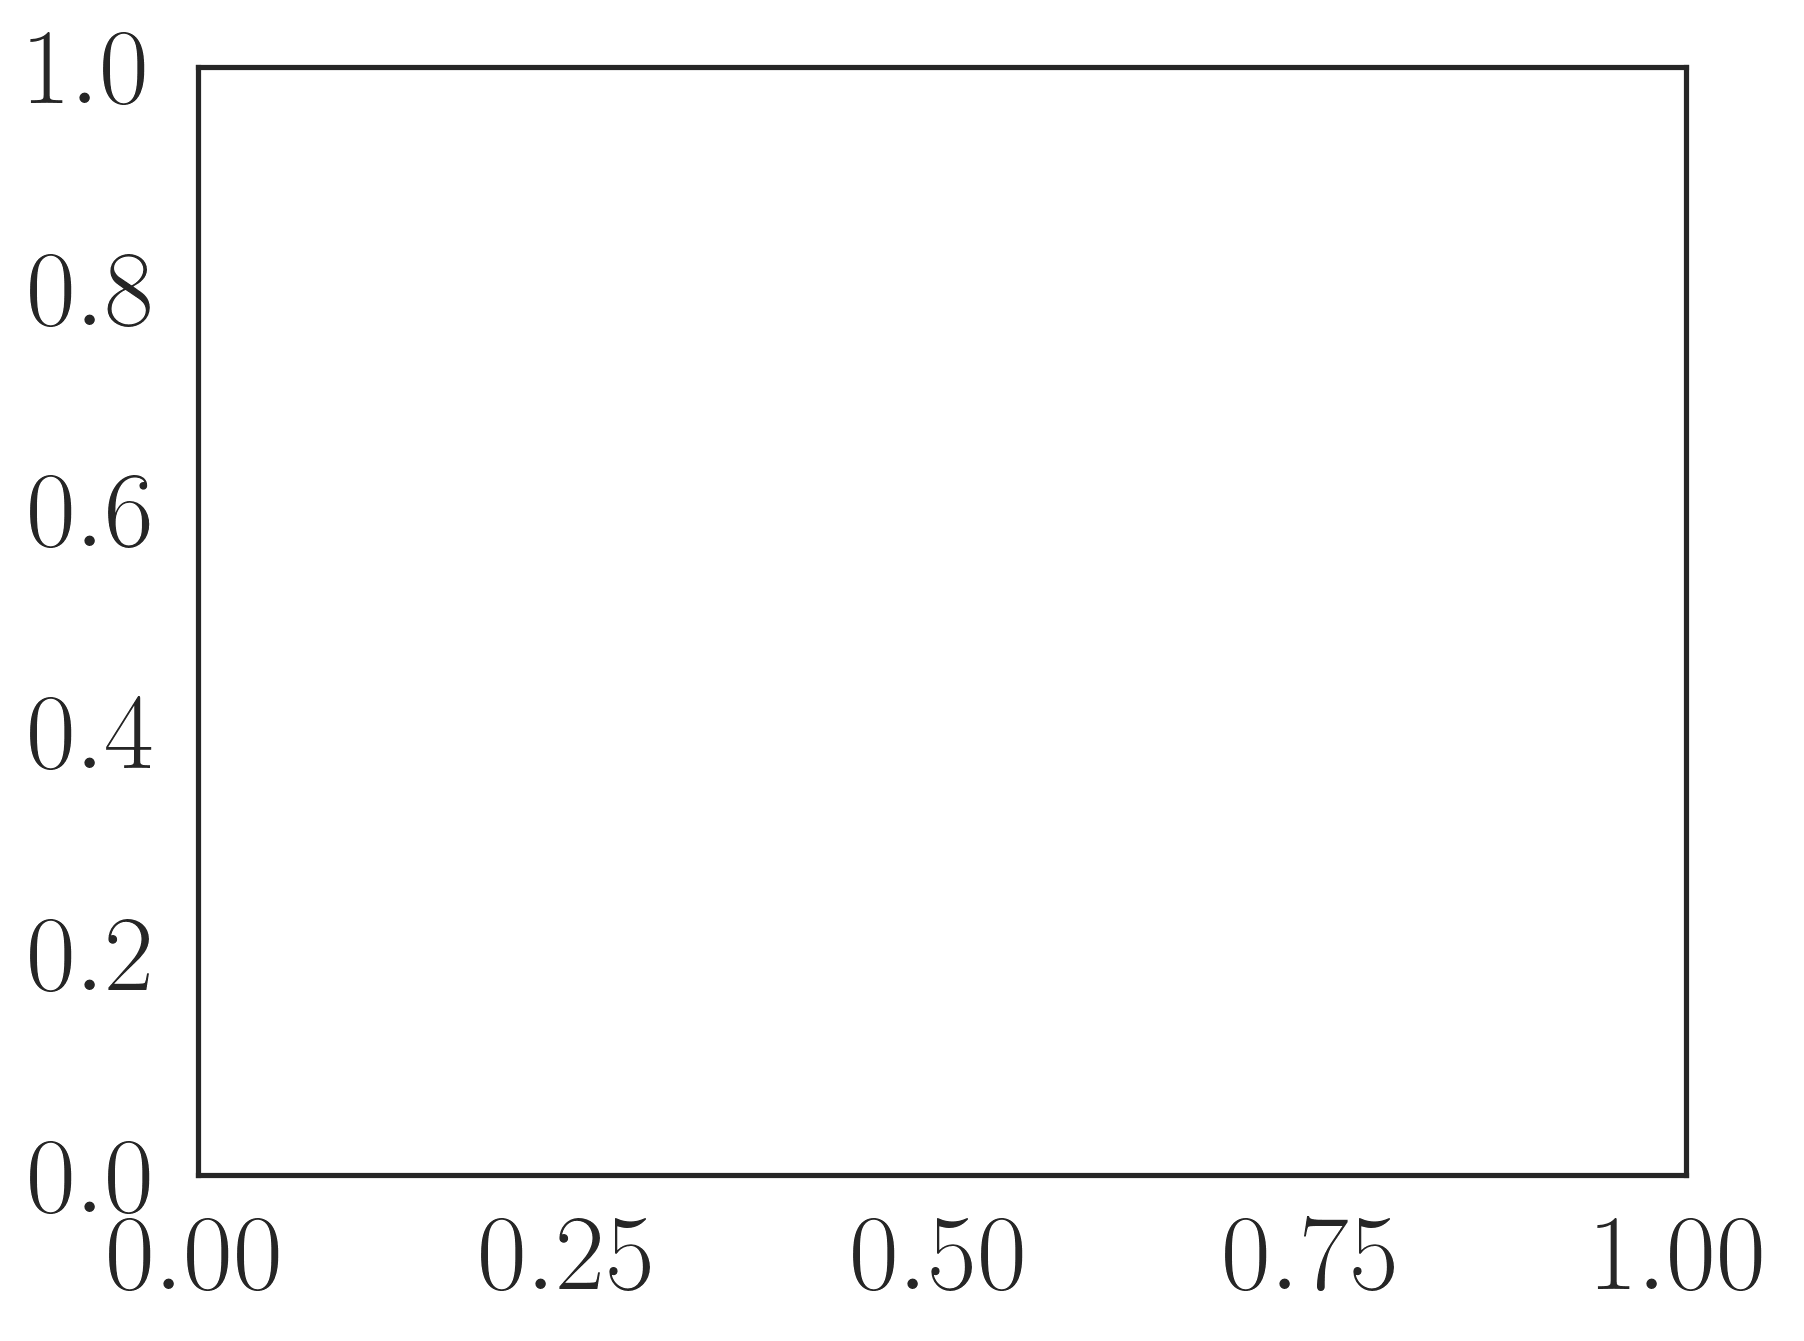

In [9]:
# Load data
data = np.load(dump_path, allow_pickle=True)
#print(data.shape)

# Extract information to plot
adam_loss = data["adam_loss_history"]
lbfgs_loss = data["lbfgs_inner_curve"]

adam_time = data["adam_time"]
lbfgs_time = data["lbfgs_time"]
print(adam_time)
print(lbfgs_time)

#adam_epochs = data["adam_epochs"]
#lbfgs_iters = data["lbfgs_iters"]

total_time = data["total_training_time"]
print(total_time)

# Merge Adam + LBFGS
#loss_full = np.concatenate([adam_loss, lbfgs_loss])
#time_full = np.concatenate([adam_time, lbfgs_time])

### Plots

# 
plt.plot(adam_epochs, adam_loss, label="Adam")
#plt.plot(len(adam_epochs) + lbfgs_iters, lbfgs_loss, label="LBFGS")
plt.yscale("log")
plt.xlabel("Epoch / Iteration")
plt.ylabel("Loss")
plt.legend()

# 
plt.plot(time_full, loss_full)
plt.yscale("log")
plt.xlabel("Wall time [s]")
plt.ylabel("Loss")
plt.title("Training convergence")

#• npz -- u, loss vs epoch/interation, residuals R(x,t), loss vs wall time; 
#  • save the times: Adam vs. LBFGS -> wall time two axis. Save # Adam and LBFGS
#  • report for 4 PINNs: SA-ACTO, ACTO, SA, VANILLA
#  • write another code that uses Cole-Hopf to generate the analytical solution, take both solutions and compare them (PINNs predictions vs. analytical solutions)
#  • take both solutions and plot L^2 error vs. epoch/wall-time, simulation time

#plots 
#• loss vs epoch/wall-time for all methods for all problems
#• L2 error to ground truth solution vs epoch/wall-time for all methods for all problems
#• L2(x,t) (heatmap). By the way, don't plot L2 directly, but clip it, like L2\_plot = max(L2,1e-16). Otherwise, if there is a point where L2 is 0, plotting in log-scale will make it crash ($\log 0 = -\infty$).


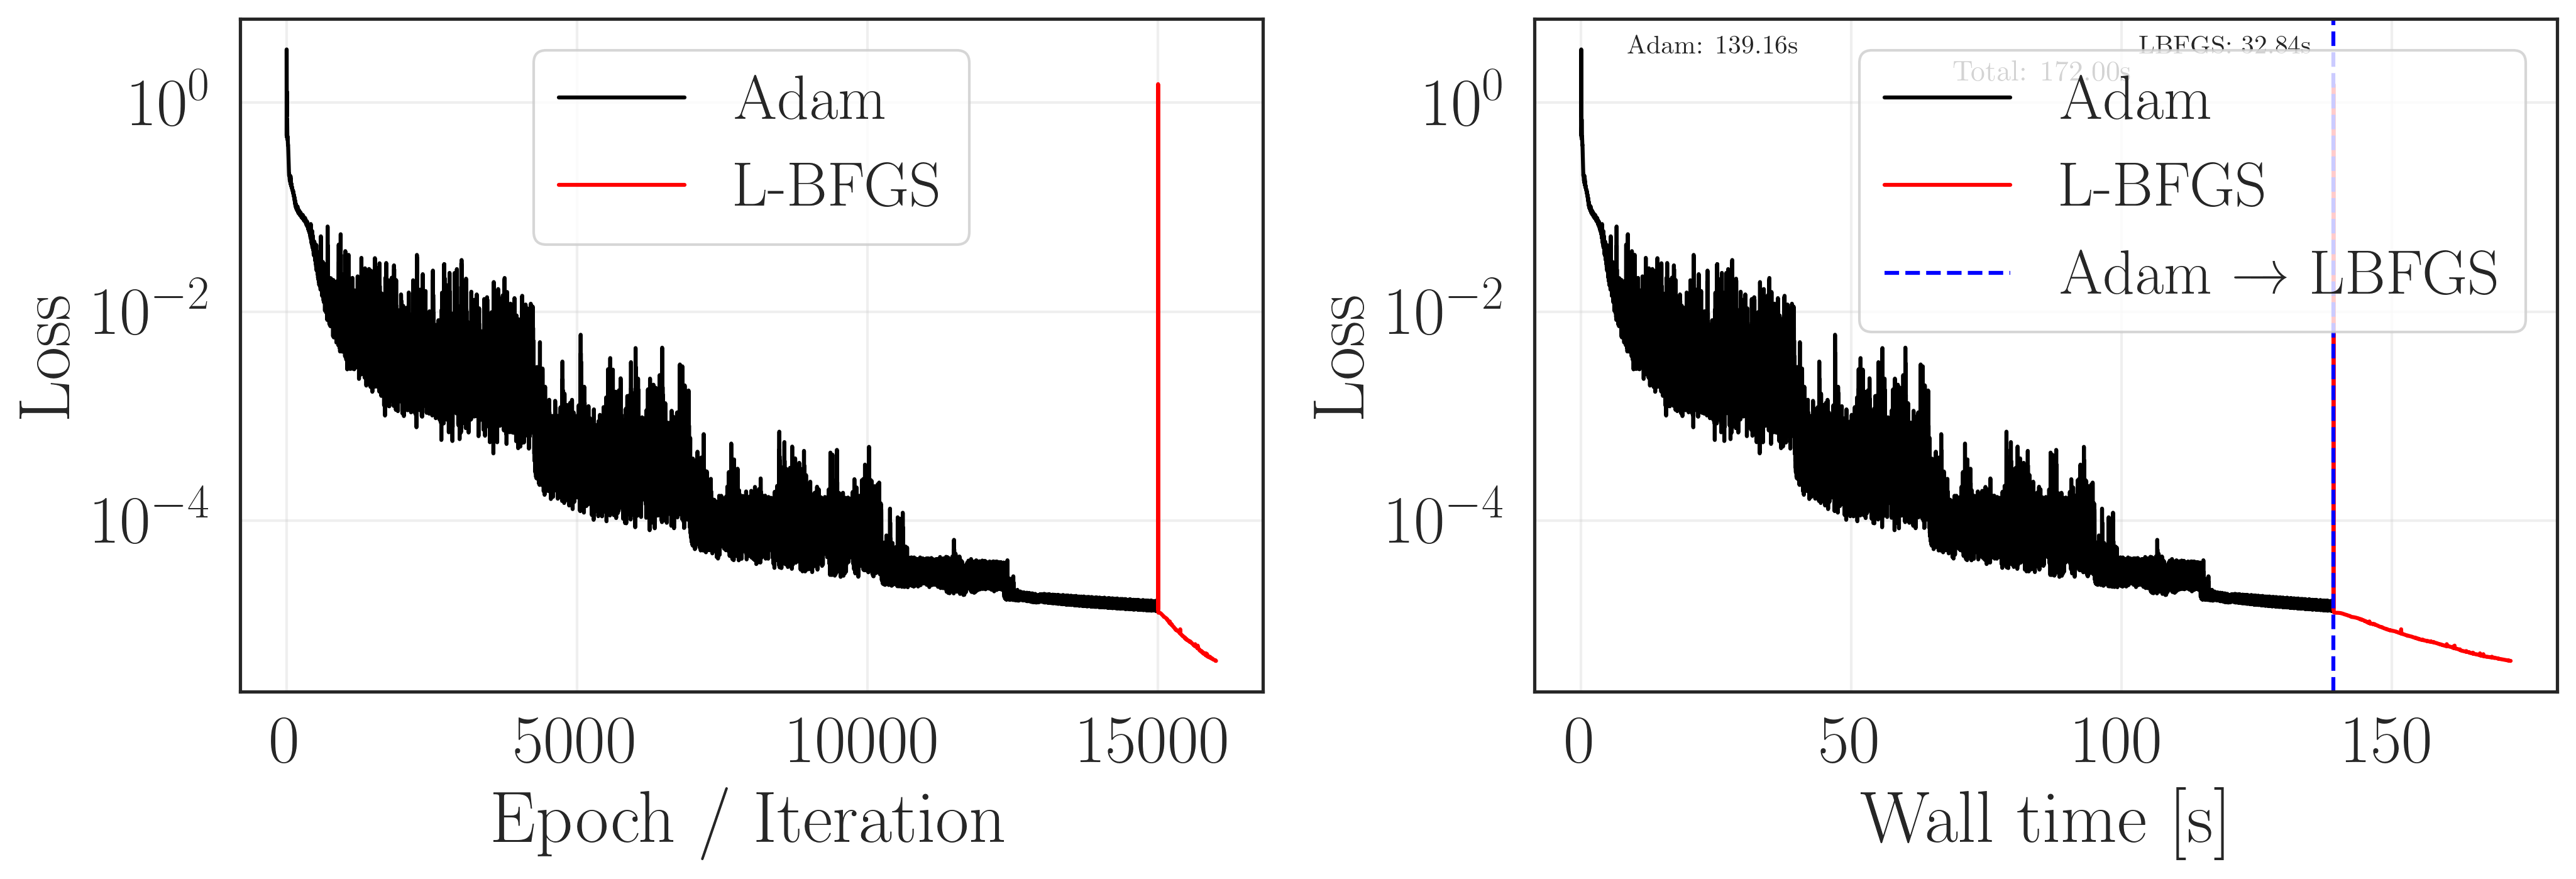

NameError: name 'u_gt_on_p' is not defined

In [13]:
def plot_loss_with_time(data):
    import numpy as np
    import matplotlib.pyplot as plt

    adam_loss = data["adam_loss_history"]
    lbfgs_loss = data["lbfgs_inner_curve"]

    adam_time = float(data["adam_time"])
    lbfgs_time = float(data["lbfgs_time"])
    total_time = float(data["total_training_time"])

    # --- Build iteration axes ---
    adam_epochs = np.arange(len(adam_loss))
    lbfgs_iters = np.arange(len(lbfgs_loss)) + len(adam_loss)

    # --- Approximate time axes ---
    adam_dt = adam_time / max(len(adam_loss), 1)
    lbfgs_dt = lbfgs_time / max(len(lbfgs_loss), 1)

    adam_time_axis = adam_epochs * adam_dt
    lbfgs_time_axis = adam_time + np.arange(len(lbfgs_loss)) * lbfgs_dt

    # ==========================
    # FIGURE
    # ==========================
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # ----------------------------------
    # (1) Loss vs iteration
    # ----------------------------------
    axs[0].plot(adam_epochs, adam_loss, label="Adam", color="black")
    axs[0].plot(lbfgs_iters, lbfgs_loss, label="L-BFGS", color="red")

    axs[0].set_yscale("log")
    axs[0].set_xlabel("Epoch / Iteration")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # ----------------------------------
    # (2) Loss vs wall-time
    # ----------------------------------
    axs[1].plot(adam_time_axis, adam_loss, label="Adam", color="black")
    axs[1].plot(lbfgs_time_axis, lbfgs_loss, label="L-BFGS", color="red")

    axs[1].set_yscale("log")
    axs[1].set_xlabel("Wall time [s]")
    axs[1].set_ylabel("Loss")
    axs[1].grid(alpha=0.3)

    # Mark transitions
    axs[1].axvline(adam_time, linestyle="--", color="blue", label="Adam → LBFGS")

    # Annotate times
    axs[1].text(0.05 * total_time, 0.9 * max(adam_loss),
                f"Adam: {adam_time:.2f}s", fontsize=10)

    axs[1].text(0.6 * total_time, 0.9 * max(adam_loss),
                f"LBFGS: {lbfgs_time:.2f}s", fontsize=10)

    axs[1].text(0.4 * total_time, 0.5 * max(adam_loss),
                f"Total: {total_time:.2f}s", fontsize=11, weight="bold")

    axs[1].legend()

    plt.tight_layout()
    plt.show()

t_eval = data["t_eval"]

def plot_error_vs_simulation_time(u_pred, u_gt, t_eval):
    import numpy as np
    import matplotlib.pyplot as plt

    Nt = len(t_eval)

    # L2 over space for each time
    errors = []
    for i in range(Nt):
        num = np.linalg.norm(u_pred[i] - u_gt[i])
        den = np.linalg.norm(u_gt[i])
        errors.append(0 if den == 0 else num / den)

    errors = np.array(errors)

    plt.figure(figsize=(6, 4))
    plt.plot(t_eval, errors, color="black")
    plt.yscale("log")
    plt.xlabel("Simulation time t")
    plt.ylabel("Relative $L^2$ error")
    plt.title("Error evolution in physical time")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_loss_with_time(data)

plot_error_vs_simulation_time(
    u_pred=data["u_grid"],
    u_gt=u_gt_on_p,
    t_eval=data["t_eval"]
)   